In [ ]:
!pip install jax-fem meshio gmsh --quiet
# JAX'ın GPU sürümünü Colab'da doğrula
import jax
print(f"Cihaz: {jax.devices()}") # 'gpu' görmelisin

Cihaz: [CpuDevice(id=0)]


In [ ]:
!apt-get install -y libglu1-mesa libxcursor1 libxinerama1 libxft2 libxrender1

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libxcursor1 is already the newest version (1:1.2.0-2build4).
libxcursor1 set to manually installed.
libxft2 is already the newest version (2.3.4-1).
libxft2 set to manually installed.
libxinerama1 is already the newest version (2:1.1.4-3).
libxinerama1 set to manually installed.
libxrender1 is already the newest version (1:0.9.10-1build4).
The following NEW packages will be installed:
  libglu1-mesa
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 145 kB of archives.
After this operation, 367 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libglu1-mesa amd64 9.0.2-1 [145 kB]
Fetched 145 kB in 1s (173 kB/s)
Selecting previously unselected package libglu1-mesa:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../libglu1-mesa_9.0.2-1_amd64.deb ...
Unpacking libglu1-mes

In [ ]:
!pip install gmsh

In [ ]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
import gmsh
import numpy as np

print(f"Aktif Cihaz: {jax.devices()}") # 'gpu' görmelisin

Aktif Cihaz: [CpuDevice(id=0)]


In [ ]:
!pip install scikit-fem[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 2.7 MB/s eta 0:00:00


In [ ]:
import os, gmsh, h5py, numpy as np, matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from skfem import *
from skfem import utils
from skfem.models.poisson import laplace, mass
from multiprocessing import Pool, cpu_count
from tqdm.notebook import tqdm

# Ayarlar
H5_FILENAME = "rf_cavity_1000_dataset.h5"
PLOT_DIR = "dataset_plots"
N_TOTAL = 1000
N_PLOT = 100
os.makedirs(PLOT_DIR, exist_ok=True)

# ============================================================================
# 1. OPTİMİZE EDİLMİŞ GEOMETRİ & MESH MOTORU
# ============================================================================
def generate_sample_data(s_id):
    try:
        gmsh.initialize()
        gmsh.model.add(f"rf_{s_id}")
        np.random.seed(s_id * 13)
        L, cx, cy = 0.1, 0.05, 0.05

        # Geometrik Çeşitlilik: Keskin köşeler ve kaotik bloblar
        method = np.random.choice(['sharp', 'smooth'])
        if method == 'sharp':
            n_pts = np.random.randint(7, 13)
            angles = np.sort(np.random.uniform(0, 2*np.pi, n_pts))
            r = np.random.uniform(0.02, 0.046, n_pts)
            pts_c = [(cx + ri*np.cos(ai), cy + ri*np.sin(ai)) for ri, ai in zip(r, angles)]
        else:
            t = np.linspace(0, 2*np.pi, 100, endpoint=False)
            r = 0.035 + sum(np.random.uniform(-0.008, 0.008) * np.cos(k*t + np.random.uniform(0, 2*np.pi)) for k in range(2, 8))
            pts_c = [(cx + ri*np.cos(ti), cy + ri*np.sin(ti)) for ri, ti in zip(r, t)]

        pts = [gmsh.model.occ.addPoint(p[0], p[1], 0) for p in pts_c]
        lines = [gmsh.model.occ.addLine(pts[i], pts[(i+1)%len(pts)]) for i in range(len(pts))]
        gmsh.model.occ.addPlaneSurface([gmsh.model.occ.addCurveLoop(lines)])
        gmsh.model.occ.synchronize()

        # Adaptif Mesh: Sınırda yoğun, merkezde dengeli
        gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
        gmsh.model.mesh.field.add("Distance", 1)
        gmsh.model.mesh.field.setNumbers(1, "CurvesList", lines)
        gmsh.model.mesh.field.add("Threshold", 2)
        gmsh.model.mesh.field.setNumber(2, "InField", 1)
        gmsh.model.mesh.field.setNumber(2, "SizeMin", 0.0012)
        gmsh.model.mesh.field.setNumber(2, "SizeMax", 0.005)
        gmsh.model.mesh.field.setNumber(2, "DistMin", 0.002)
        gmsh.model.mesh.field.setNumber(2, "DistMax", 0.03)
        gmsh.model.mesh.field.setAsBackgroundMesh(2)

        gmsh.model.mesh.generate(2)
        _, coords, _ = gmsh.model.mesh.getNodes()
        _, _, conns = gmsh.model.mesh.getElements(2)
        nodes = np.ascontiguousarray(coords.reshape(-1, 3)[:, :2])
        elements = np.ascontiguousarray((conns[0].reshape(-1, 3) - 1).astype(np.int32))
        gmsh.finalize()

        # Physics Solver (P2 Precision)
        m = MeshTri(nodes.T, elements.T)
        basis = Basis(m, ElementTriP2())
        K, M = laplace.assemble(basis), mass.assemble(basis)
        D = basis.get_dofs(facets=m.boundary_facets())
        Kc, Mc, xc, Ic = utils.condense(K, M, D=D, expand=True)
        vals, vecs = utils.solve_eigen(Kc, Mc, x=xc, I=Ic, k=3, sigma=500.0)

        freqs = (299792458 * np.sqrt(np.abs(vals.real))) / (2 * np.pi) / 1e9

        return {
            'id': s_id, 'nodes': nodes, 'elements': elements,
            'freqs': freqs.real, 'vecs': vecs.real, 'n_nodes': len(nodes)
        }
    except Exception as e:
        return None

# ============================================================================
# 2. GÖRSELLEŞTİRME YARDIMCISI
# ============================================================================
def save_sample_plot(data, save_path):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    nodes, elements = data['nodes'], data['elements']
    triang = Triangulation(nodes[:, 0], nodes[:, 1], elements)

    # Mesh Panel
    axes[0].triplot(triang, color='gray', linewidth=0.15, alpha=0.5)
    axes[0].set_title(f"ID {data['id']}: {len(elements)} Elements")

    for i in range(3):
        # P2'den ilk n_nodes kadarını görselleştirme için al
        mode_v = data['vecs'][:data['n_nodes'], i]
        mode_norm = mode_v / np.max(np.abs(mode_v))
        axes[i+1].tripcolor(triang, mode_norm, shading='gouraud', cmap='RdBu_r', vmin=-1, vmax=1)
        axes[i+1].set_title(f"Mode {i+1}: {data['freqs'][i]:.4f} GHz")

    for ax in axes: ax.set_aspect('equal'); ax.axis('off')
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.close()

# ============================================================================
# 3. ANA DÖNGÜ & HDF5 PAKETLEME
# ============================================================================
if __name__ == '__main__':
    print(f"🚀 {cpu_count()} çekirdek ile 1000 örnek üretiliyor...")

    with h5py.File(H5_FILENAME, "w") as f_h5:
        with Pool(cpu_count()) as pool:
            # Örnekleri chunklar halinde işle (bellek yönetimi için)
            for i in tqdm(range(0, N_TOTAL, 50), desc="Toplu Üretim"):
                chunk_range = range(i, min(i + 50, N_TOTAL))
                chunk_results = pool.map(generate_sample_data, chunk_range)

                for res in chunk_results:
                    if res is None: continue

                    # H5 Kayıt (Gzip sıkıştırma ile)
                    grp = f_h5.create_group(f"sample_{res['id']:04d}")
                    grp.create_dataset("nodes", data=res['nodes'], compression="gzip", compression_opts=4)
                    grp.create_dataset("elements", data=res['elements'], compression="gzip", compression_opts=4)
                    grp.create_dataset("freqs", data=res['freqs'])
                    grp.create_dataset("vecs", data=res['vecs'], compression="gzip", compression_opts=4)

                    # İlk 100 tanesini görsel olarak kaydet
                    if res['id'] < N_PLOT:
                        plot_path = os.path.join(PLOT_DIR, f"sample_{res['id']:03d}.png")
                        save_sample_plot(res, plot_path)

    print(f"\n✅ Tamamlandı! \n📦 Dosya: {H5_FILENAME} \n🖼️ Görseller: {PLOT_DIR}/")

🚀 2 çekirdek ile 1000 örnek üretiliyor...


Toplu Üretim:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/skfem/utils.py:216: ComplexWarning: Casting complex values to real discards the imaginary part
  y[I] = X
/usr/local/lib/python3.12/dist-packages/skfem/utils.py:216: ComplexWarning: Casting complex values to real discards the imaginary part
  y[I] = X



✅ Tamamlandı! 
📦 Dosya: rf_cavity_1000_dataset.h5 
🖼️ Görseller: dataset_plots/


# Dataset(distance to center)

In [ ]:
"""
RF Cavity HDF5 Dataset'ini GNOT Formatına Çevirme
"""

import h5py
import numpy as np
import pickle
from pathlib import Path
from tqdm import tqdm
from typing import List, Tuple, Optional


class RFCavityToGNOT:
    """
    RF cavity modal analiz verilerini GNOT formatına çevir

    GNOT Format: [X, Y, Theta, Input_funcs]
    - X: (N, 2) - mesh node koordinatları [x, y]
    - Y: (N, n_modes) - modal shapes (eigenvector değerleri)
    - Theta: (n_params,) - [mode_index, frequency, ...] global parametreler
    - Input_funcs: tuple - geometry encoding ve ek bilgiler
    """

    def __init__(self, h5_filepath: str):
        self.h5_filepath = h5_filepath
        self.h5_file = None
        self.dataset = []

    def open_h5(self):
        """HDF5 dosyasını aç"""
        self.h5_file = h5py.File(self.h5_filepath, 'r')
        print(f"📂 HDF5 opened: {self.h5_filepath}")
        print(f"   Total samples: {len(self.h5_file.keys())}")

    def close_h5(self):
        """HDF5 dosyasını kapat"""
        if self.h5_file:
            self.h5_file.close()

    def add_geometric_features(self, nodes: np.ndarray, elements: np.ndarray) -> np.ndarray:
        """
        Geometrik özellikler ekle (isteğe bağlı)

        Returns:
            (N, feature_dim) - geometric features
        """
        # Merkeze göre uzaklık
        center = nodes.mean(axis=0)
        dist_to_center = np.linalg.norm(nodes - center, axis=1, keepdims=True)

        # Sınır noktalarını tespit et
        # Basit yöntem: En dış noktalar
        boundary_mask = np.zeros((len(nodes), 1))
        hull_points = self._find_boundary_points(nodes, elements)
        boundary_mask[hull_points] = 1.0

        # Tüm özellikleri birleştir
        features = np.concatenate([
            nodes,              # (N, 2) - x, y koordinatları
            dist_to_center,     # (N, 1) - merkeze uzaklık
            boundary_mask,      # (N, 1) - sınır mı değil mi
        ], axis=1)

        return features

    def _find_boundary_points(self, nodes: np.ndarray, elements: np.ndarray) -> np.ndarray:
        """
        Sınır noktalarını bul (triangle mesh'ten)
        """
        # Kenarları say - sınırda olan kenarlar sadece 1 kez geçer
        from collections import defaultdict
        edge_count = defaultdict(int)

        for tri in elements:
            edges = [
                (min(tri[0], tri[1]), max(tri[0], tri[1])),
                (min(tri[1], tri[2]), max(tri[1], tri[2])),
                (min(tri[2], tri[0]), max(tri[2], tri[0]))
            ]
            for edge in edges:
                edge_count[edge] += 1

        # Sadece 1 kez geçen kenarlar sınırda
        boundary_edges = [edge for edge, count in edge_count.items() if count == 1]
        boundary_nodes = set()
        for edge in boundary_edges:
            boundary_nodes.add(edge[0])
            boundary_nodes.add(edge[1])

        return np.array(list(boundary_nodes))

    def convert_sample_to_gnot(
        self,
        sample_data: dict,
        mode_indices: List[int] = [0, 1, 2],
        include_geometry_features: bool = True,
        normalize_modes: bool = True,
    ) -> List:
        """
        Tek bir HDF5 sample'ı GNOT formatına çevir

        Args:
            sample_data: HDF5'ten okunan dict {'nodes', 'elements', 'freqs', 'vecs'}
            mode_indices: Hangi modları dahil edeceğiz
            include_geometry_features: Geometrik özellikleri Input_funcs'a ekle
            normalize_modes: Modal shape'leri normalize et

        Returns:
            List of GNOT samples - her mod için ayrı bir sample
        """
        nodes = sample_data['nodes']          # (N, 2)
        elements = sample_data['elements']    # (M, 3)
        freqs = sample_data['freqs']          # (n_modes,)
        vecs = sample_data['vecs']            # (N_expanded, n_modes) - P2 nodes

        # P2 elementten sadece orijinal node sayısını al
        n_nodes = len(nodes)
        vecs_trimmed = vecs[:n_nodes, :]  # P2'den P1'e dönüş

        gnot_samples = []

        for mode_idx in mode_indices:
            if mode_idx >= len(freqs):
                continue

            # X: Mesh koordinatları
            X = nodes.astype(np.float32)  # (N, 2)

            # Y: Modal shape (eigenvector)
            mode_shape = vecs_trimmed[:, mode_idx].astype(np.float32)

            if normalize_modes:
                # Normalize: [-1, 1] aralığına
                mode_max = np.abs(mode_shape).max()
                if mode_max > 1e-10:
                    mode_shape = mode_shape / mode_max

            Y = mode_shape.reshape(-1, 1)  # (N, 1) - GNOT requires 2D

            # Theta: Global parametreler
            # [mode_index, frequency_GHz, sample_id]
            Theta = np.array([
                float(mode_idx),
                float(freqs[mode_idx]),
                float(sample_data.get('sample_id', 0))
            ], dtype=np.float32)

            # Input_funcs: Geometrik özellikler
            if include_geometry_features:
                geom_features = self.add_geometric_features(nodes, elements)
                Input_funcs = (geom_features.astype(np.float32),)
            else:
                Input_funcs = (None,)

            # GNOT sample
            gnot_sample = [X, Y, Theta, Input_funcs]
            gnot_samples.append(gnot_sample)

        return gnot_samples

    def convert_full_dataset(
        self,
        output_filepath: str,
        mode_indices: List[int] = [0, 1, 2],
        max_samples: Optional[int] = None,
        include_geometry_features: bool = True,
    ):
        """
        Tüm HDF5 dataset'ini GNOT formatına çevir

        Args:
            output_filepath: GNOT dataset'in kaydedileceği yer (.pkl)
            mode_indices: Dahil edilecek modlar
            max_samples: En fazla kaç sample işlensin (None = hepsi)
            include_geometry_features: Geometri özelliklerini ekle
        """

        self.open_h5()
        self.dataset = []

        sample_keys = sorted(self.h5_file.keys())
        if max_samples:
            sample_keys = sample_keys[:max_samples]

        print(f"\n🔄 Converting {len(sample_keys)} samples to GNOT format...")
        print(f"   Mode indices: {mode_indices}")
        print(f"   Geometry features: {include_geometry_features}")

        for sample_key in tqdm(sample_keys, desc="Converting"):
            try:
                grp = self.h5_file[sample_key]

                sample_data = {
                    'nodes': grp['nodes'][:],
                    'elements': grp['elements'][:],
                    'freqs': grp['freqs'][:],
                    'vecs': grp['vecs'][:],
                    'sample_id': int(sample_key.split('_')[-1])
                }

                # Her mod için ayrı GNOT sample oluştur
                gnot_samples = self.convert_sample_to_gnot(
                    sample_data,
                    mode_indices=mode_indices,
                    include_geometry_features=include_geometry_features,
                )

                self.dataset.extend(gnot_samples)

            except Exception as e:
                print(f"❌ Error processing {sample_key}: {e}")
                continue

        self.close_h5()

        # Kaydet
        self.save_dataset(output_filepath)

        return self.dataset

    def save_dataset(self, filepath: str):
        """GNOT dataset'i kaydet"""
        filepath = Path(filepath)
        filepath.parent.mkdir(parents=True, exist_ok=True)

        with open(filepath, 'wb') as f:
            pickle.dump(self.dataset, f)

        print(f"\n✅ GNOT Dataset saved: {filepath}")
        print(f"   Total GNOT samples: {len(self.dataset)}")

        if len(self.dataset) > 0:
            X, Y, Theta, Input_funcs = self.dataset[0]
            print(f"\n📊 Sample 0 info:")
            print(f"   X shape: {X.shape} (mesh coordinates)")
            print(f"   Y shape: {Y.shape} (modal shape)")
            print(f"   Theta: {Theta} [mode_idx, freq_GHz, sample_id]")
            if Input_funcs[0] is not None:
                print(f"   Geometry features shape: {Input_funcs[0].shape}")

    @staticmethod
    def load_gnot_dataset(filepath: str) -> List:
        """GNOT dataset'i yükle"""
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)

        print(f"📂 GNOT Dataset loaded: {filepath}")
        print(f"   Total samples: {len(dataset)}")

        return dataset

    @staticmethod
    def print_dataset_stats(dataset: List):
        """Dataset istatistiklerini yazdır"""
        print("\n📈 Dataset Statistics:")
        print(f"   Total samples: {len(dataset)}")

        # Mesh boyutları
        mesh_sizes = [sample[0].shape[0] for sample in dataset]
        print(f"   Mesh sizes: min={min(mesh_sizes)}, max={max(mesh_sizes)}, avg={np.mean(mesh_sizes):.1f}")

        # Frekans dağılımı
        freqs = [sample[2][1] for sample in dataset]  # Theta[1] = frequency
        print(f"   Frequencies [GHz]: min={min(freqs):.4f}, max={max(freqs):.4f}")

        # Mod dağılımı
        mode_counts = {}
        for sample in dataset:
            mode_idx = int(sample[2][0])  # Theta[0] = mode_index
            mode_counts[mode_idx] = mode_counts.get(mode_idx, 0) + 1
        print(f"   Mode distribution: {mode_counts}")


# ============================================================================
# KULLANIM ÖRNEĞİ
# ============================================================================
if __name__ == "__main__":

    # Parametreler
    H5_FILE = "rf_cavity_1000_dataset.h5"
    OUTPUT_PKL = "gnot_rf_cavity_dataset.pkl"

    # Converter oluştur
    converter = RFCavityToGNOT(H5_FILE)

    # Tüm dataset'i çevir
    # İlk 3 modu dahil et (mode 0, 1, 2)
    dataset = converter.convert_full_dataset(
        output_filepath=OUTPUT_PKL,
        mode_indices=[0, 1, 2],
        max_samples=None,  # Tümünü işle (1000 sample x 3 mode = 3000 GNOT sample)
        include_geometry_features=True,
    )

    # İstatistikleri göster
    RFCavityToGNOT.print_dataset_stats(dataset)

    # Test: Veriyi geri yükle
    print("\n🧪 Testing load...")
    loaded_dataset = RFCavityToGNOT.load_gnot_dataset(OUTPUT_PKL)

    # İlk sample'ı detaylı incele
    print("\n🔍 First sample details:")
    X, Y, Theta, Input_funcs = loaded_dataset[0]
    print(f"   X (coords): shape={X.shape}, range=[{X.min():.4f}, {X.max():.4f}]")
    print(f"   Y (mode shape): shape={Y.shape}, range=[{Y.min():.4f}, {Y.max():.4f}]")
    print(f"   Theta: {Theta}")
    if Input_funcs[0] is not None:
        print(f"   Geometry features: shape={Input_funcs[0].shape}")
        print(f"      [x, y, dist_to_center, is_boundary]")

📂 HDF5 opened: rf_cavity_1000_dataset.h5
   Total samples: 999

🔄 Converting 999 samples to GNOT format...
   Mode indices: [0, 1, 2]
   Geometry features: True


Converting: 100%|██████████| 999/999 [00:44<00:00, 22.28it/s]



✅ GNOT Dataset saved: gnot_rf_cavity_dataset.pkl
   Total GNOT samples: 2997

📊 Sample 0 info:
   X shape: (1462, 2) (mesh coordinates)
   Y shape: (1462, 1) (modal shape)
   Theta: [0.        3.7276037 0.       ] [mode_idx, freq_GHz, sample_id]
   Geometry features shape: (1462, 4)

📈 Dataset Statistics:
   Total samples: 2997
   Mesh sizes: min=546, max=2351, avg=1560.5
   Frequencies [GHz]: min=3.3421, max=15.0110
   Mode distribution: {0: 999, 1: 999, 2: 999}

🧪 Testing load...
📂 GNOT Dataset loaded: gnot_rf_cavity_dataset.pkl
   Total samples: 2997

🔍 First sample details:
   X (coords): shape=(1462, 2), range=[0.0077, 0.0891]
   Y (mode shape): shape=(1462, 1), range=[0.0000, 1.0000]
   Theta: [0.        3.7276037 0.       ]
   Geometry features: shape=(1462, 4)
      [x, y, dist_to_center, is_boundary]


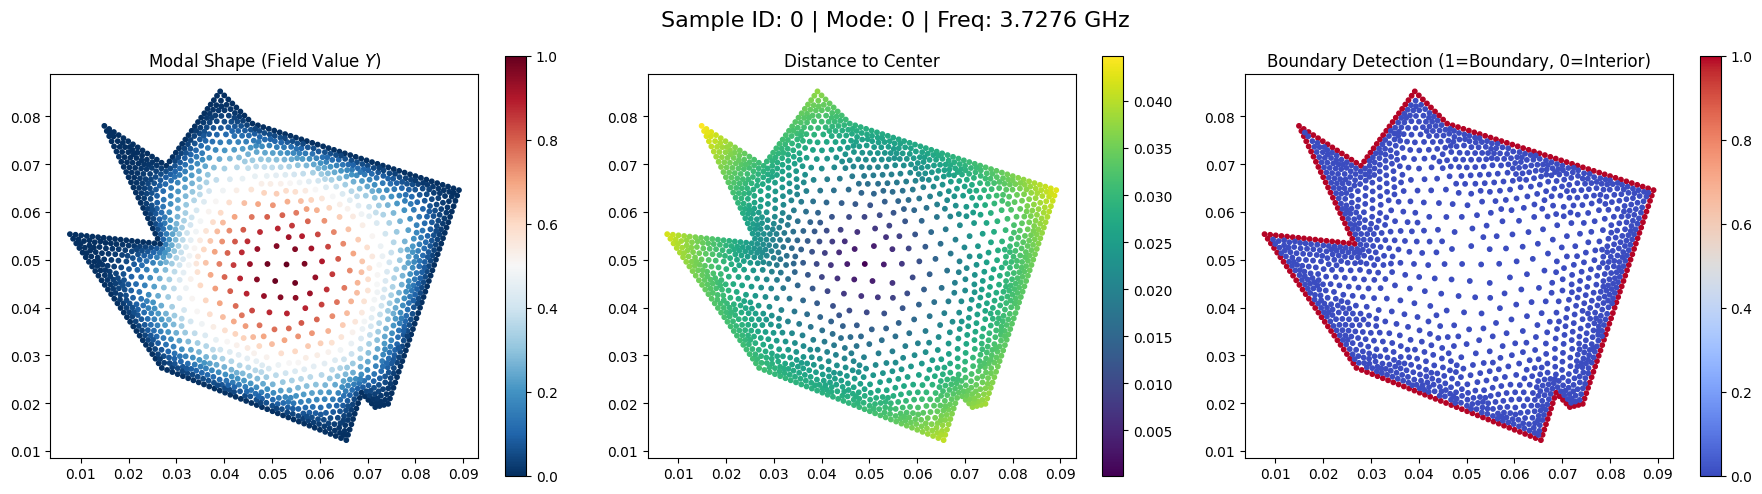

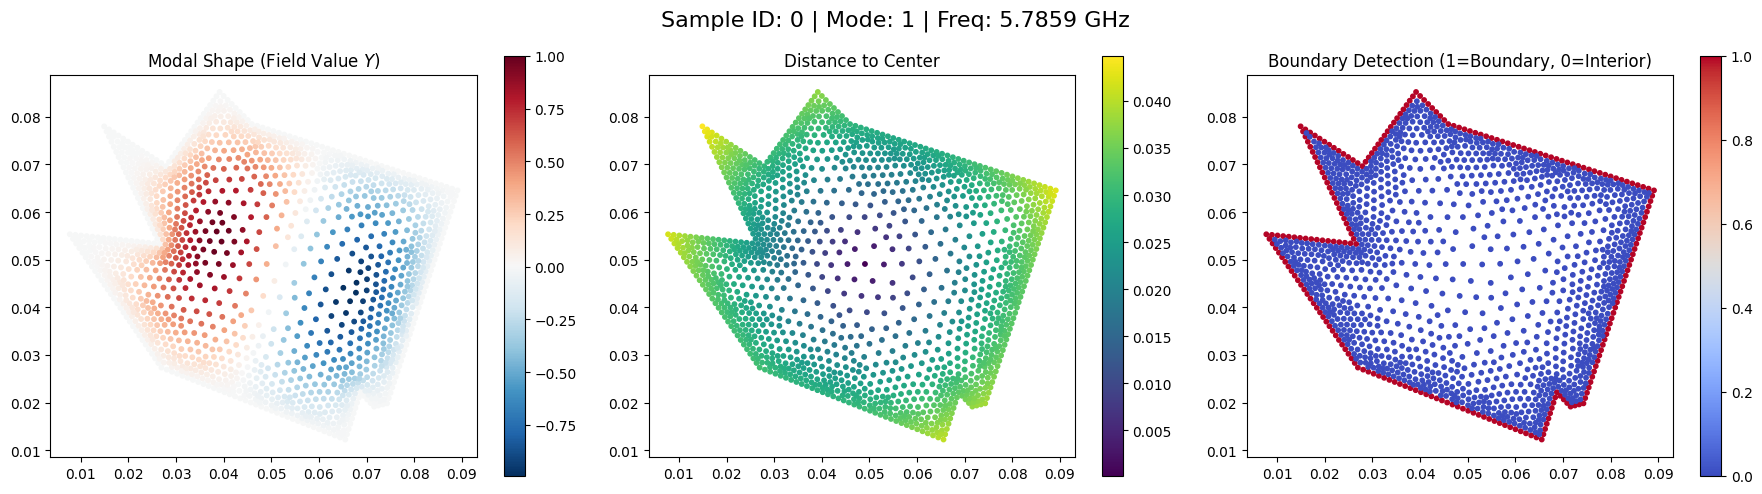

In [ ]:
import matplotlib.pyplot as plt

def visualize_gnot_sample(sample):
    """
    GNOT formatındaki tek bir sample'ı görselleştirir.
    """
    X, Y, Theta, Input_funcs = sample
    geom_features = Input_funcs[0]

    # Parametreleri al (Theta: [mode_idx, freq_GHz, sample_id])
    mode_idx = int(Theta[0])
    freq = Theta[1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Sample ID: {int(Theta[2])} | Mode: {mode_idx} | Freq: {freq:.4f} GHz", fontsize=16)

    # 1. Modal Shape (Y Değerleri)
    # X[:, 0] -> x koordinatı, X[:, 1] -> y koordinatı
    sc1 = axes[0].scatter(X[:, 0], X[:, 1], c=Y.flatten(), cmap='RdBu_r', s=10)
    axes[0].set_title("Modal Shape (Field Value $Y$)")
    axes[0].set_aspect('equal')
    plt.colorbar(sc1, ax=axes[0])

    # 2. Distance to Center (Geometrik Özellik 1)
    if geom_features is not None:
        dist_to_center = geom_features[:, 2] # dist_to_center sütunu
        sc2 = axes[1].scatter(X[:, 0], X[:, 1], c=dist_to_center, cmap='viridis', s=10)
        axes[1].set_title("Distance to Center")
        axes[1].set_aspect('equal')
        plt.colorbar(sc2, ax=axes[1])

        # 3. Boundary Mask (Geometrik Özellik 2)
        boundary_mask = geom_features[:, 3] # is_boundary sütunu
        sc3 = axes[2].scatter(X[:, 0], X[:, 1], c=boundary_mask, cmap='coolwarm', s=10)
        axes[2].set_title("Boundary Detection (1=Boundary, 0=Interior)")
        axes[2].set_aspect('equal')
        plt.colorbar(sc3, ax=axes[2])

    plt.tight_layout()
    plt.show()

# Kullanımı:
if 'loaded_dataset' in locals() and len(loaded_dataset) > 0:
    visualize_gnot_sample(loaded_dataset[0])
    visualize_gnot_sample(loaded_dataset[1])

# Dataset(sdf)

🔄 Çevriliyor: 100%|██████████| 999/999 [00:37<00:00, 26.75it/s]



✅ İşlem Tamam! optimized_dataset.pkl oluşturuldu.


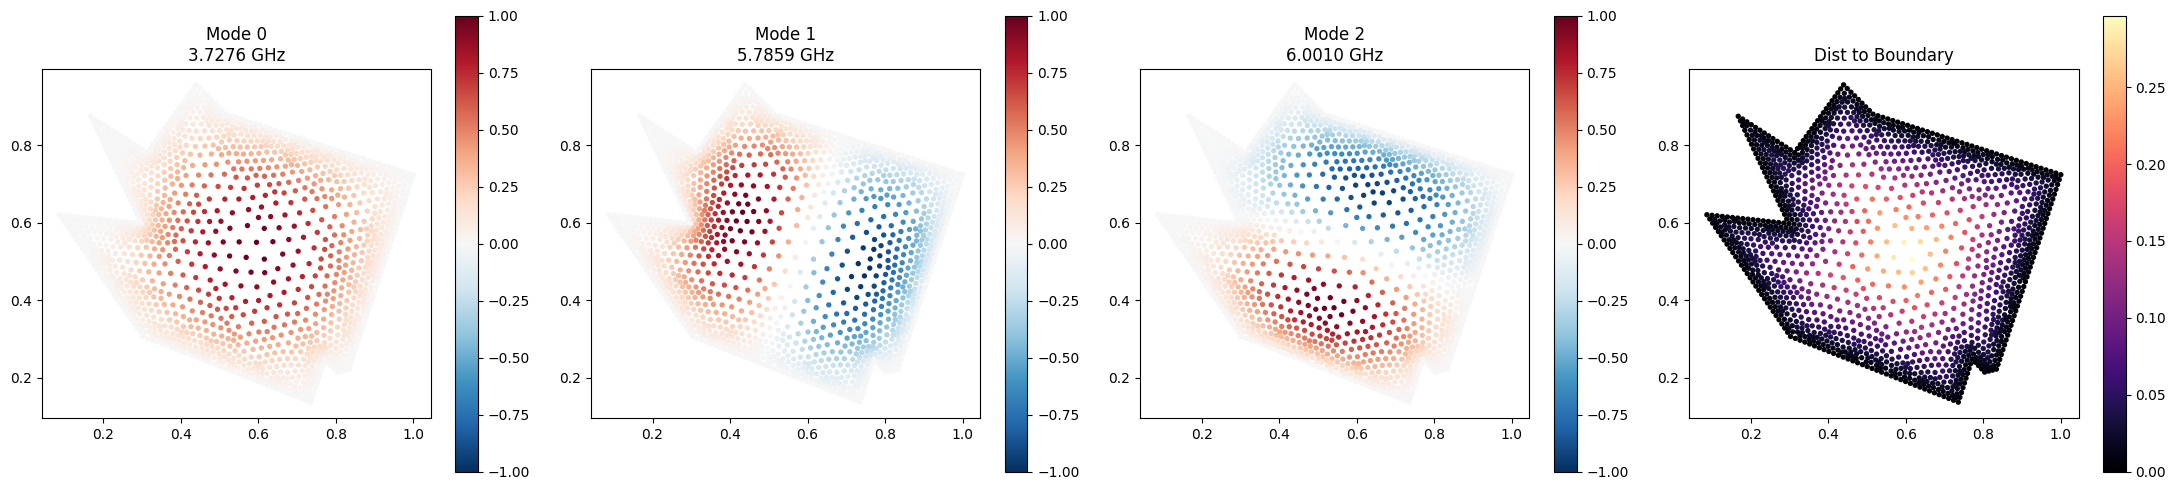

In [ ]:
import h5py
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.spatial import cKDTree

class RFCavityToGNOT:
    def __init__(self, h5_filepath: str):
        self.h5_filepath = h5_filepath
        self.geometry_pool = {}
        self.samples = []

    def _find_boundary_nodes(self, elements: np.ndarray) -> np.ndarray:
        edge_count = {}
        for tri in elements:
            edges = [tuple(sorted((tri[0], tri[1]))),
                     tuple(sorted((tri[1], tri[2]))),
                     tuple(sorted((tri[2], tri[0])))]
            for e in edges:
                edge_count[e] = edge_count.get(e, 0) + 1
        return np.array(list({node for edge, count in edge_count.items() if count == 1 for node in edge}))

    def extract_geometry_features(self, nodes, elements):
        """
        Geometriyi oranlarını bozmadan, en büyük koordinatı 1.0
        olacak şekilde ölçekler.
        """
        # 1. Mevcut en büyük koordinat değerini bul (x veya y fark etmez)
        scale_factor = nodes.max() + 1e-10

        # 2. Tüm noktaları bu tek sayıya böl (Isotropic Scaling)
        nodes_norm = nodes / scale_factor

        # 3. Sınır noktalarını bul ve mesafeyi hesapla
        # Not: Mesafe de artık 0-1 aralığında anlamlı bir ölçekte olacak.
        boundary_indices = self._find_boundary_nodes(elements)
        tree = cKDTree(nodes_norm[boundary_indices])
        dist_to_boundary, _ = tree.query(nodes_norm)

        # 4. Özellikleri birleştir [x, y, dist, mask]
        boundary_mask = np.zeros((len(nodes), 1))
        boundary_mask[boundary_indices] = 1.0

        geom_features = np.concatenate([
            nodes_norm,
            dist_to_boundary.reshape(-1, 1),
            boundary_mask
        ], axis=1).astype(np.float32)

        return {
            'X': nodes_norm.astype(np.float32),
            'Input_funcs': (geom_features,)
        }



    def convert_dataset(self, output_filepath, mode_indices=[0, 1, 2]):
        with h5py.File(self.h5_filepath, 'r') as f:
            sample_keys = sorted(f.keys())
            for key in tqdm(sample_keys, desc="🔄 Çevriliyor"):
                grp = f[key]
                sample_id = int(key.split('_')[-1])
                nodes, elements = grp['nodes'][:], grp['elements'][:]

                if sample_id not in self.geometry_pool:
                    self.geometry_pool[sample_id] = self.extract_geometry_features(nodes, elements)

                freqs, vecs = grp['freqs'][:], grp['vecs'][:len(nodes), :]
                for m_idx in mode_indices:
                    if m_idx >= len(freqs): continue
                    Y = vecs[:, m_idx].reshape(-1, 1).astype(np.float32)
                    # İşaret Hizalama & Normalizasyon
                    sign = np.sign(Y[np.argmax(np.abs(Y))])
                    Y = (Y * sign) / (np.abs(Y).max() + 1e-10)
                    theta = np.array([float(m_idx), float(freqs[m_idx]), float(sample_id)], dtype=np.float32)
                    self.samples.append({'geom_id': sample_id, 'Y': Y, 'Theta': theta})

        with open(output_filepath, 'wb') as f:
            pickle.dump({'geometry_pool': self.geometry_pool, 'samples': self.samples}, f)
        print(f"\n✅ İşlem Tamam! {output_filepath} oluşturuldu.")

# ============================================================================
# GÖRSELLEŞTİRME VE ÇALIŞTIRMA MANTIĞI
# ============================================================================

def run_and_visualize(h5_path, pkl_path):
    # 1. Çeviriciyi çalıştır
    converter = RFCavityToGNOT(h5_path)
    converter.convert_dataset(pkl_path)

    # 2. Kaydedilen dosyayı test için yükle
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    # 3. Görselleştir (İlk geometriye ait modlar)
    sample_id_to_show = 0 # İlk geometri
    pool = data['geometry_pool']
    relevant_samples = [s for s in data['samples'] if s['geom_id'] == sample_id_to_show]
    geom = pool[sample_id_to_show]

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for i, sample in enumerate(relevant_samples[:3]):
        X, Y, Theta = geom['X'], sample['Y'], sample['Theta']
        sc = axes[i].scatter(X[:, 0], X[:, 1], c=Y.flatten(), cmap='RdBu_r', s=8, vmin=-1, vmax=1)
        axes[i].set_title(f"Mode {int(Theta[0])}\n{Theta[1]:.4f} GHz")
        axes[i].set_aspect('equal')
        plt.colorbar(sc, ax=axes[i])

    # Geometrik mesafe özelliği
    dist_feat = geom['Input_funcs'][0][:, 2]
    sc_geo = axes[3].scatter(geom['X'][:, 0], geom['X'][:, 1], c=dist_feat, cmap='magma', s=8)
    axes[3].set_title("Dist to Boundary")
    axes[3].set_aspect('equal')
    plt.colorbar(sc_geo, ax=axes[3])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # DOSYA YOLLARINI BURADAN AYARLA
    MY_H5_FILE = "rf_cavity_1000_dataset.h5"
    MY_OUTPUT_PKL = "optimized_dataset.pkl"

    run_and_visualize(MY_H5_FILE, MY_OUTPUT_PKL)

In [ ]:
from google.colab import files
import os

files.download("rf_cavity_1000_dataset.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
